<a href="https://colab.research.google.com/github/andrexmueller/2048/blob/main/Trabalho_FPLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Comparação socioeconômica entre segurados do INSS e a população geral a partir de dados de concessão e indeferimento de benefícios (dezembro/2025).

## 1. Introdução

A presente Análise Exploratória de Dados (AED) tem como objetivo compreender o perfil dos segurados do INSS e compará-lo ao perfil mais amplo da população brasileira.

As bases de dados utilizadas foram obtidas a partir do portal de Dados Abertos do Governo Federal e referem-se ao mês de dezembro de 2025.

Serão analisadas a quantidade, distribuição e proporção dos tipos de benefícios, bem como a renda associada, segmentadas por sexo, idade, grau de instrução e unidade da federação.

Seerão também comparadas as quantidades e proporções entre benefícios concedidos e indeferidos, buscando identificar padrões relevantes e possíveis desigualdades entre os grupos analisados.

## 2. Importação dos Dados

Nesta etapa, serão importadas as bibliotecas Python necessárias para a análise e o carregamento das bases de dados.

Os dados serão organizados em estruturas do tipo DataFrame, utilizando a biblioteca Pandas.

Devido ao formato e tamanho dos arquivos disponibilizados pelo Governo Federal, optou-se por não fazer o carregamento dos dados diretamente do sítio dos Dados Abertos. Os dados foram baixados localmente e tratados de modo que, do formato ".xlsx" original, foram transformados no formato ".parquet" e disponibilizados um repositório do Github.

In [255]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import requests
import certifi
import ssl
import urllib3
import re


sns.set_theme(style="darkgrid")

In [256]:
url_indeferidos = 'https://github.com/andrexmueller/mba/releases/download/df_conc122025/indef12205.parquet'
url_concedidos = 'https://github.com/andrexmueller/mba/releases/download/df_conc122025/conc122025.parquet'
url_pop_estados = 'https://github.com/andrexmueller/mba/releases/download/df_conc122025/POP2025_20260113.csv'
url_pop_renda = 'https://github.com/andrexmueller/mba/releases/download/df_conc122025/renda2024.csv'

urllib3.disable_warnings()

def carrega_parquet(url: str) -> pd.DataFrame:
    response = requests.get(url, verify=False)

    with open("dados", "wb") as f:
        f.write(response.content)

    df = pd.read_parquet("dados")
    os.remove("dados")

    return df

def carrega_csv(url: str, **params) -> pd.DataFrame:
    response = requests.get(url, verify=False)

    with open("dados", "wb") as f:
        f.write(response.content)

    df = pd.read_csv('dados', sep=params['sep'], encoding=params['encoding'],
                      header=params['header'], skipfooter=params['skipfooter'],
                     engine='python')

    os.remove("dados")

    return df


con = carrega_parquet(url_concedidos)
ind = carrega_parquet(url_indeferidos)
pop = carrega_csv(url_pop_estados, sep=';', encoding='latin', header=1, skipfooter=4)
ren = carrega_csv(url_pop_renda, sep=';', encoding='latin', header=1, skipfooter=2)

In [257]:
url_indeferidos = 'https://github.com/andrexmueller/mba/releases/download/df_conc122025/indef12205.parquet'
url_concedidos = 'https://github.com/andrexmueller/mba/releases/download/df_conc122025/conc122025.parquet'
url_pop_estados = 'https://github.com/andrexmueller/mba/releases/download/df_conc122025/POP2025_20260113.csv'
url_pop_renda = 'https://github.com/andrexmueller/mba/releases/download/df_conc122025/renda2024.csv'


def carrega_parquet(url: str) -> pd.DataFrame:
    response = requests.get(url, verify=False)

    with open("dados", "wb") as f:
        f.write(response.content)

    df = pd.read_parquet("dados")
    os.remove("dados")

    return df

def carrega_csv(url: str, **params) -> pd.DataFrame:
    response = requests.get(url, verify=False)

    with open("dados", "wb") as f:
        f.write(response.content)

    df = pd.read_csv('dados', sep=params['sep'], encoding=params['encoding'],
                      header=params['header'], skipfooter=params['skipfooter'], engine='python')

    os.remove("dados")

    return df


In [258]:
con = carrega_parquet(url_concedidos)
ind = carrega_parquet(url_indeferidos)
pop = carrega_csv(url_pop_estados, sep=';', encoding='latin', header=1, skipfooter=4)
ren = carrega_csv(url_pop_renda, sep=';', encoding='latin', header=1, skipfooter=2)

## 3. Tratamento e Normalização dos Dados

In [259]:
# constantes utilizads

FATOR_NS_ANOS = 10**9 * 60 * 60 * 24 * 365
FATOR_NS_DIAS = 10**9 * 60 * 60 * 24
SM_2024 = 1412.


def trata_concedidos(df: pd.DataFrame) -> pd.DataFrame:

    # Descarta das colunas que não serão utilizadas
    df.drop(columns=['Competência concessão', 'País de Acordo Internacional',
                  'Classificador PA', 'CNAE 2.0', 'CNAE 2.0.1'], inplace=True)

    # Formatao as colunas com datas
    cols_datas = ['Dt Nascimento', 'Dt DIB', 'Dt DDB', 'Dt DCB']
    for col in cols_datas:
        df[col] = pd.to_datetime(con[col], errors='coerce')

    # Cria uma coluna com a idade do segurado, em anos
    df['Idade'] = ((df['Dt DDB'] - df['Dt Nascimento']).astype('int64') / FATOR_NS_ANOS)

    # Cria uma coluna com o tempo entre o início do benefício (DIB) e a sua concessção (DDB)
    df['TMC'] = ((df['Dt DDB'] - df['Dt DIB']).astype('int64') / FATOR_NS_DIAS).astype('int64')

    return df


def trata_indeferidos(df: pd.DataFrame) -> pd.DataFrame:

    # Forma das colunas com datas
    cols_datas = ['Dt Nascimento', 'Dt DER', 'Dt Indeferimento']
    for col in cols_datas:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # Cria uma coluna com a idade do segurado, em anos
    df['Idade'] = ((df['Dt Indeferimento'] - df['Dt Nascimento']).astype('int64') / FATOR_NS_ANOS)

    # Cria uma coluna com o tempo entre o início do benefício (DIB) e a sua concessção (DDB)
    df['TMC'] = ((df['Dt Indeferimento'] - df['Dt DER']).astype('int64') / FATOR_NS_DIAS).astype('int64')

    return df

def trata_renda(df: pd.DataFrame) -> pd.DataFrame:
    # Renomeia colunas de forma mais conveniente
    df = df.rename(columns={'Unidades da Federação': 'UF', 'Rendimento nominal mensal domiciliar per capita da população residente (R$)': 'Renda'})

    # Calcula renda em quantidade de salários mínimos
    df['Qtde SM'] = df['Renda'].map(lambda r: float(r.replace(',', '.')) * 1000 / SM_2024)

    return df


def trata_pop(df: pd.DataFrame) -> pd.DataFrame:
    # Renomeia colunas de forma mais conveniente
    df = df.rename(columns={'BRASIL E UNIDADES DA FEDERAÇÃO': 'UF',  'POPULAÇÃO ESTIMADA': 'População'})
    df = df.drop('Unnamed: 2', axis=1)
    pop_brasil = df.iloc[0, 1]
    df['Proporção'] = df['População'] / pop_brasil

    return df



In [260]:
con = carrega_parquet(url_concedidos)
ind = carrega_parquet(url_indeferidos)
pop = carrega_csv(url_pop_estados, sep=';', encoding='latin', header=1, skipfooter=4)
ren = carrega_csv(url_pop_renda, sep=';', encoding='latin', header=1, skipfooter=2)

In [261]:
con = trata_concedidos(con)
ind = trata_indeferidos(ind)
ren = trata_renda(ren)
pop = trata_pop(pop)

In [262]:
con.value_counts(['APS', 'APS.1', 'UF'])

,,,count
APS,APS.1,UF,
23001240,23001240-Aps de Automatizacao de Processos,Distrito Federal,77995
11030040,11030040-Aps Uberlandia,Minas Gerais,2598
21025010,21025010-Aps Guarulhos,São Paulo,2573
17024040,17024040-Aps Petropolis,Rio de Janeiro,2423
20024030,20024030-Aps Joinville - Centro,Santa Catarina,2262
...,...,...,...
11027003,11027003-SADJ Ouro Preto,Minas Gerais,1
21004010,21004010-Aps Sao Paulo - Nossa Senhora de Sab,São Paulo,1
12001330,12001330-Aps Demandas Judiciais Belem,Pará,1


In [263]:
ind.value_counts(['APS', 'APS.1', 'UF'])

,,,count
APS,APS.1,UF,
23001240,23001240-Aps de Automatizacao de Processos,Distrito Federal,34767
21025010,21025010-Aps Guarulhos,São Paulo,1580
11030040,11030040-Aps Uberlandia,Minas Gerais,1452
4026070,04026070-Aps Vitoria da Conquista,Bahia,1321
21026050,21026050-Aps Jundiai - Eloy Chaves,São Paulo,1266
...,...,...,...
21004010,21004010-Aps Sao Paulo - Nossa Senhora de Sab,São Paulo,1
21002050,21002050-Aps Sao Paulo - Tucuruvi,São Paulo,1
12001003,12001003-SADJ Belém,Pará,1


A APS 23001240 - Aps de Automatização de Processos, que tem o Distrito Federal como UF, centraliza nacionalmente a análise automática de requerimentos, por isso apresenta uma quantidade de benefícios muito acima de outras agências da Previdência.
Para os dados referente à concessão podemos utilizar a coluna 'Mun Resid' para obter uma distribuição por estados mais próxima da real. Mas para isso, vamos criar uma novo coluna, 'UF Res' a partir da coluna 'Mun Resid'.
A mesma técnica não é possível para a base de indeferiso, já que não tem a coluna do município de residência.

In [264]:
nomes_ufs = {
    'SP': 'São Paulo', 'MG': 'Minas Gerais', 'RJ': 'Rio de Janeiro',
    'RS': 'Rio Grande do Sul', 'PR': 'Paraná', 'BA': 'Bahia',
    'SC': 'Santa Catarina', 'CE': 'Ceará', 'PE': 'Pernambuco',
    'GO': 'Goiás', 'PA': 'Pará', 'MA': 'Maranhão', 'PB': 'Paraíba',
    'PI': 'Piauí', 'ES': 'Espírito Santo', 'MT': 'Mato Grosso',
    'RN': 'Rio Grande do Norte', 'AL': 'Alagoas', 'MS': 'Mato Grosso do Sul',
    'AM': 'Amazonas', 'DF': 'Distrito Federal', 'SE': 'Sergipe',
    'RO': 'Rondônia', 'TO': 'Tocantins', 'AC': 'Acre', 'AP': 'Amapá',
    'RR': 'Roraima'
}

con['UF Res'] = con['Mun Resid'].map(
    lambda s: None if not re.search('[A-Z]{2}', str(s)) else re.search('[A-Z]{2}', str(s)).group()
    )

In [265]:
# Adiciona uma coluna para a região do país
mapa_regioes = {
    'Acre': 'Norte', 'Alagoas': 'Nordeste', 'Amapá': 'Norte',
    'Amazonas': 'Norte', 'Bahia': 'Nordeste', 'Ceará': 'Nordeste',
    'Distrito Federal': 'Centro-Oeste', 'Espírito Santo': 'Sudeste',
    'Goiás': 'Centro-Oeste', 'Maranhão': 'Nordeste', 'Mato Grosso':
    'Centro-Oeste', 'Mato Grosso do Sul': 'Centro-Oeste', 'Minas Gerais':
    'Sudeste', 'Pará': 'Norte', 'Paraíba': 'Nordeste', 'Paraná': 'Sul',
    'Pernambuco': 'Nordeste', 'Piauí': 'Nordeste', 'Rio de Janeiro': 'Sudeste',
    'Rio Grande do Norte': 'Nordeste', 'Rio Grande do Sul': 'Sul',
    'Rondônia': 'Norte', 'Roraima': 'Norte', 'Santa Catarina': 'Sul',
    'São Paulo': 'Sudeste', 'Sergipe': 'Nordeste', 'Tocantins':  'Norte'
}

con['Região'] = con['UF Res'].map(lambda uf: mapa_regioes.get(nomes_ufs.get(uf)))



## 4. Distribuição Geográfica

Análise da distribuição regional dos benefícios concedidos  comparada à distribuição da população brasileira.

In [266]:
con_regiao = con.groupby('Região').size().reset_index(name='Qtde')
con_regiao['%Pop-Benef'] = con_regiao['Qtde'] / con_regiao['Qtde'].sum() * 100


In [267]:
regioes = 'Norte Nordeste Sudeste Sul Centro-Oeste'.split()
pop_regiao = pop.loc[pop['UF'].isin(regioes), :]
pop_regiao = pop_regiao.rename(columns={'UF': 'Região', 'Proporção': '%Pop'})
pop_regiao['%Pop'] *= 100

In [268]:
pop_regiao.merge(con_regiao, on='Região').drop(columns=['População', 'Qtde'])

,Região,%Pop,%Pop-Benef
0,Norte,8.809479,6.992619
1,Nordeste,26.822325,25.103543
2,Sudeste,41.619910,41.535499
3,Sul,14.670910,18.406169
4,Centro-Oeste,8.077375,7.962169


A distribuição dos benefícios concedidos é a mesma da distribuição populacional.

## 5. Distribuição por Sexo

Análise da Distribuição de Benefícios por sexo.
De acordo com o Censo 2022 do IBGE, as mulheres representam 51,5%, enquanto os homens 48,5% da população brasileira.

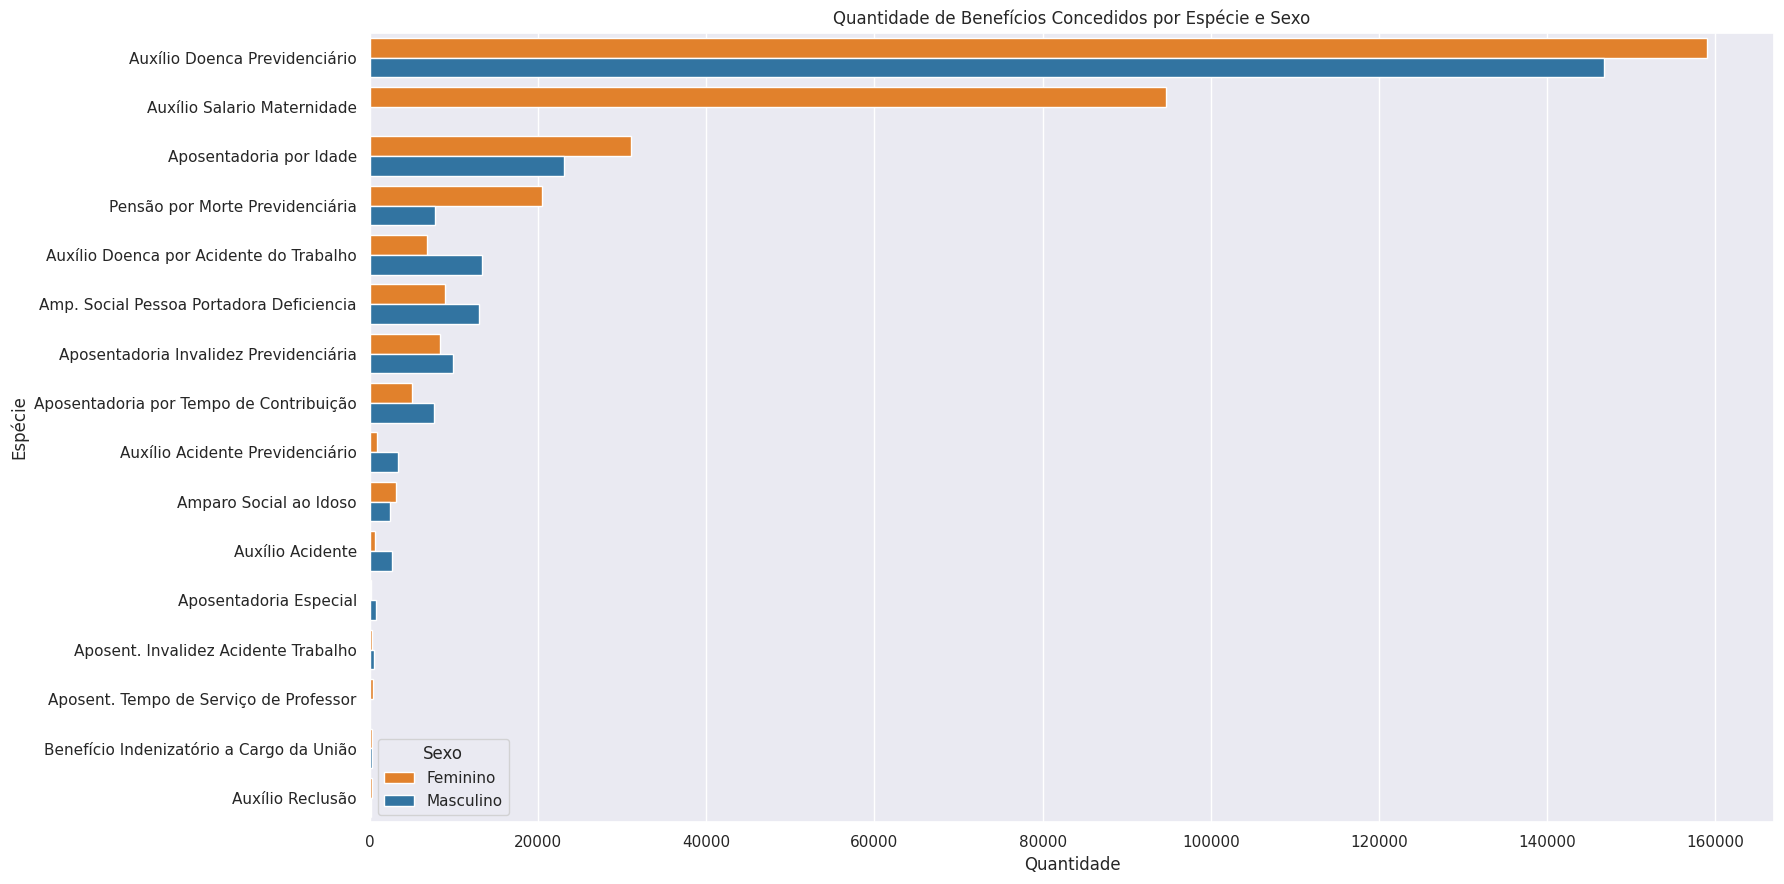

In [269]:
# Agrupa dados
grouped_data = (
    con.groupby(['Espécie.1', 'Sexo.'])['APS']
    .count()
    .reset_index(name='Count')
)

color_map = {
    'Feminino': '#ff7f0e',
    'Masculino': '#1f77b4'
}

# Mantém top 30 espécies (já ordenado)
grouped_data = grouped_data.sort_values('Count', ascending=False)
top30 = grouped_data.iloc[:30, :]

palette = [color_map[s] for s in top30['Sexo.'].unique()]

# Gráfico
plt.figure(figsize=(18, 9))

sns.barplot(
    data=top30,
    y='Espécie.1',
    x='Count',
    hue='Sexo.',
    palette=color_map

)

plt.title('Quantidade de Benefícios Concedidos por Espécie e Sexo')
plt.xlabel('Quantidade')
plt.ylabel('Espécie')

plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

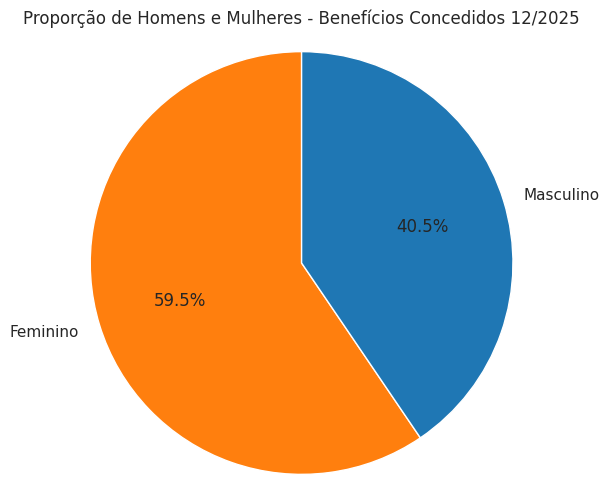

In [270]:
data = con.value_counts('Sexo.')
labels = data.index

plt.figure(figsize=(6, 6))
plt.title('Proporção de Homens e Mulheres - Benefícios Concedidos 12/2025')

plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff7f0e', '#1f77b4']
)

plt.axis('equal')
plt.show()

A porporção obtida é diferente da esperada, considerando distribuição populacional. Refazendo o cálculo, sem o benefício de Salário-Maternidade, que é pago só para mulheres, obtem se uma proporção mais próxima da esperada.

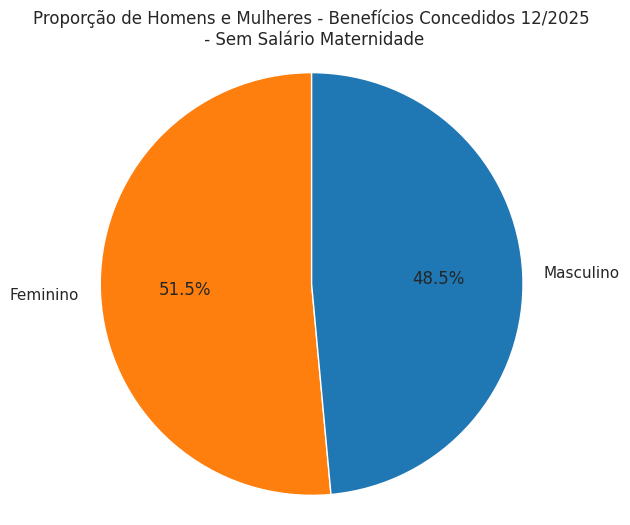

In [271]:
data = con[con['Espécie']!=80].value_counts('Sexo.')
labels = data.index

plt.figure(figsize=(6, 6))
plt.title('Proporção de Homens e Mulheres - Benefícios Concedidos 12/2025\n - Sem Salário Maternidade')

plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff7f0e', '#1f77b4']
)

plt.axis('equal')
plt.show()

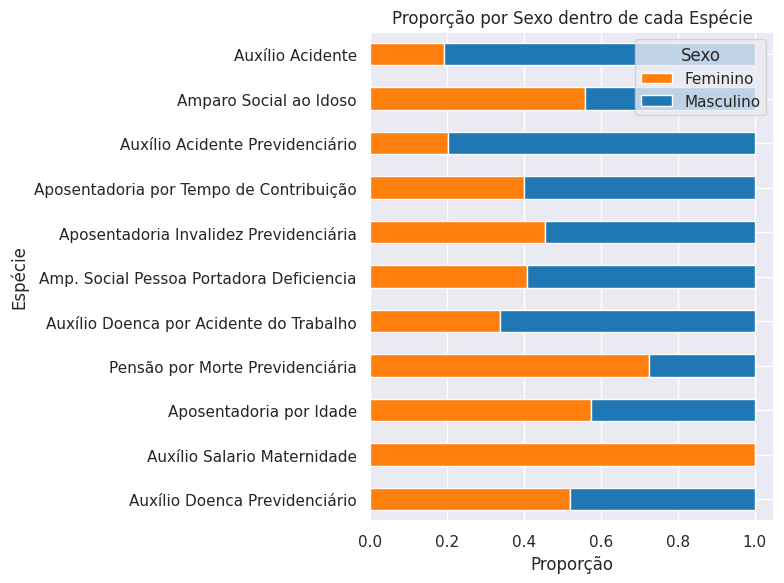

In [272]:
# Agrupa dados
prop_data = (
    grouped_data
    .pivot(index='Espécie.1', columns='Sexo.', values='Count')
    .fillna(0)
)

# Mantém top 10 espécies
grouped_data = grouped_data.sort_values('Count', ascending=False)
top = grouped_data.iloc[:20, :]

prop_data = prop_data.div(prop_data.sum(axis=1), axis=0)
prop_data = prop_data.loc[top['Espécie.1'].unique()]

prop_data.plot(
    kind='barh',
    stacked=True,
    figsize=(8, 6),
    color=['#ff7f0e', '#1f77b4']
)

plt.title('Proporção por Sexo dentro de cada Espécie')
plt.xlabel('Proporção')
plt.ylabel('Espécie')
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

## 6. Distribuição por Idade

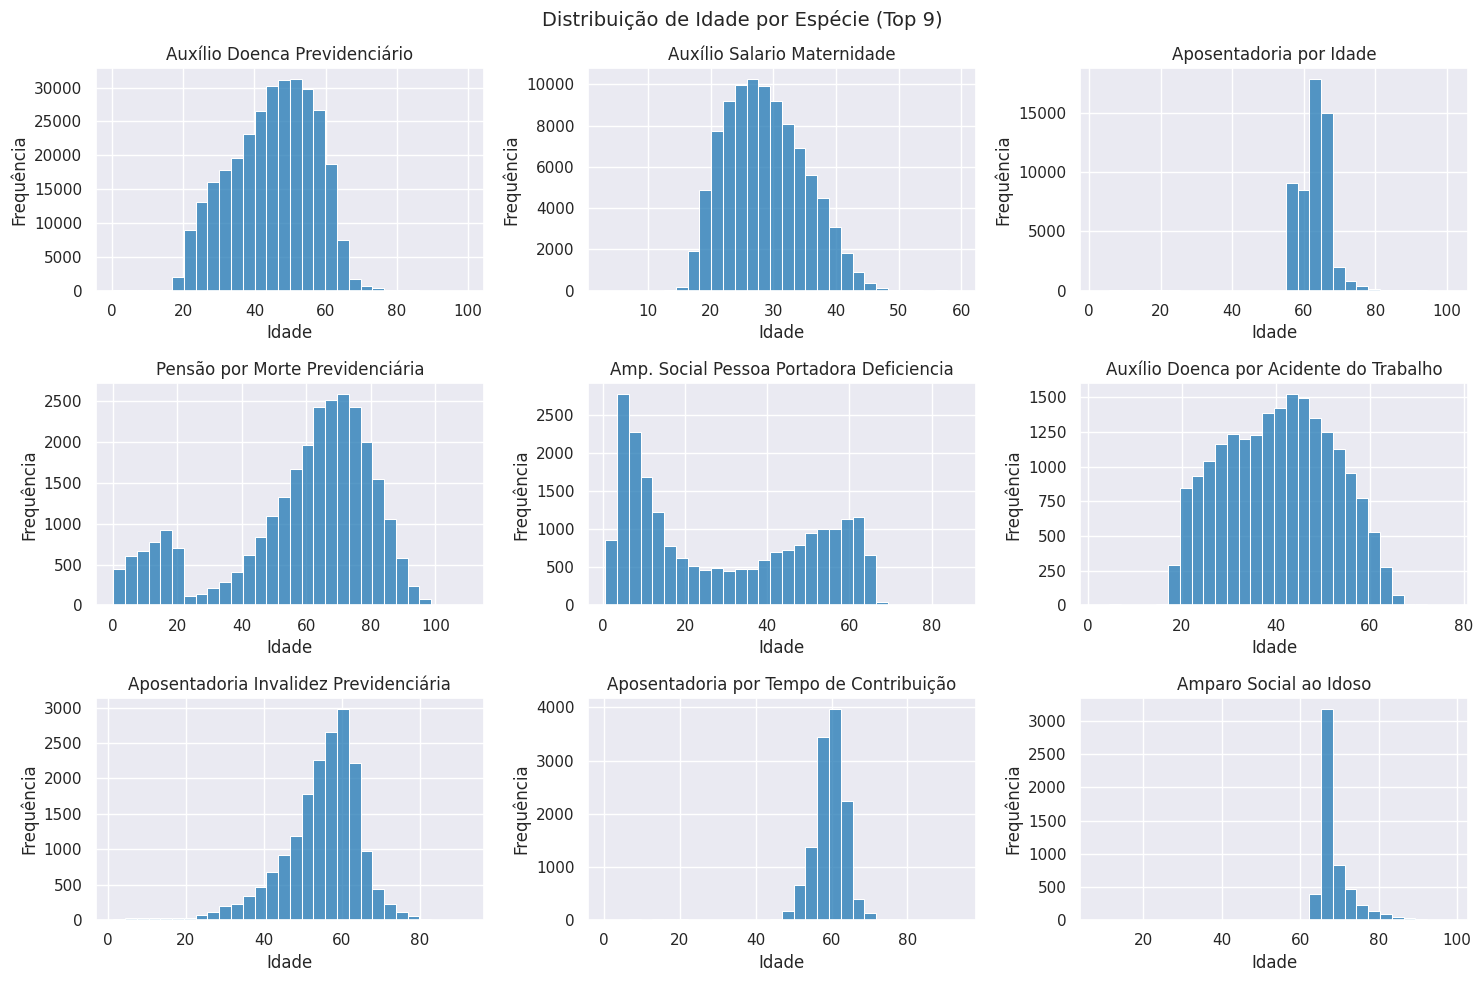

In [273]:
top_especies = con['Espécie.1'].value_counts().head(9).index
df_filtrado = con[con['Espécie.1'].isin(top_especies)]

# Subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, especie in enumerate(top_especies):
    subset = df_filtrado[df_filtrado['Espécie.1'] == especie]

    sns.histplot(
        subset['Idade'],
        bins=30,
        ax=axes[i],
        color='#1f77b4',
        edgecolor='white'
    )

    axes[i].set_title(especie)
    axes[i].set_xlabel('Idade')
    axes[i].set_ylabel('Frequência')

# Remove eixos vazios (caso sobre algum)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição de Idade por Espécie (Top 9)', fontsize=14)
plt.tight_layout()
plt.show()

Para a idade, considerando a natureza dos benefícios previdenciários, não faz sentido uma comparação direta com a pirâmide etária brasileira. Mas o padrão de distribuição etária dentro de cada espécie de benefícios é de interesse.

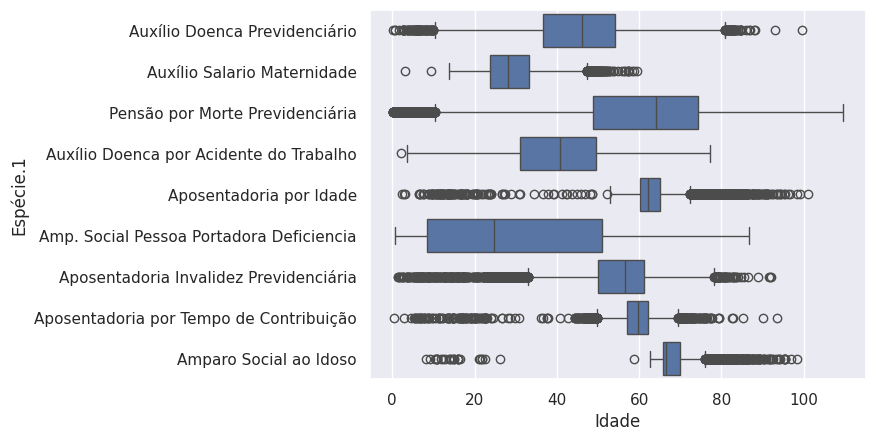

In [274]:
sns.boxplot(
    data=df_filtrado,
    y='Espécie.1',
    x='Idade',
)
plt.show()

In [275]:
# Pessoas com mais de 100 anos
con[con['Idade'] >= 100].value_counts(['Sexo.', 'Espécie.1'])

,,count
Sexo.,Espécie.1,
Masculino,Pensão por Morte Previdenciária,7
Feminino,Pensão por Morte Previdenciária,6
Masculino,Aposentadoria por Idade,1


## 7. Distribuição por Grau de Instrução

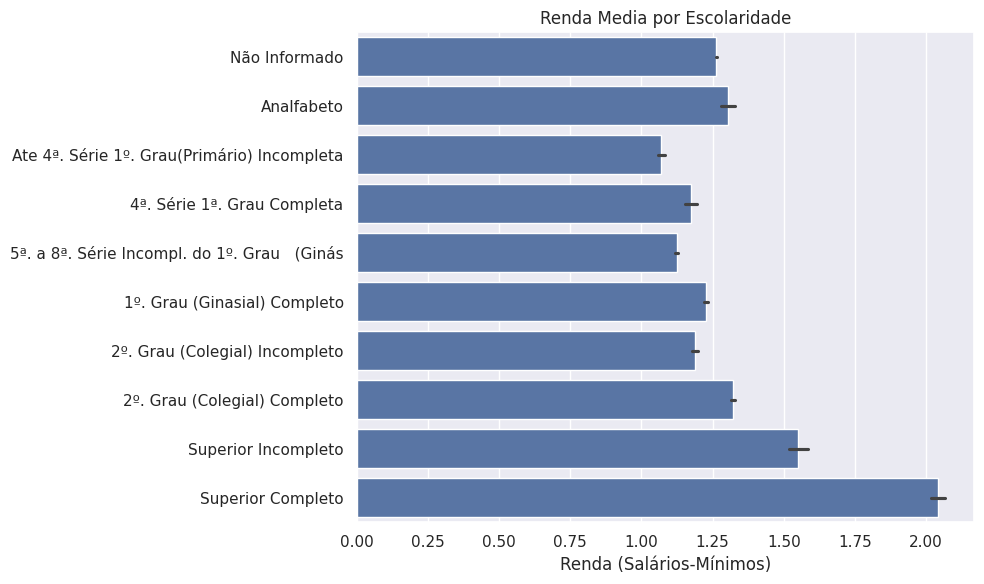

In [276]:
ordem = [
    'Não Informado',
    'Analfabeto',
    'Ate 4ª. Série 1º. Grau(Primário) Incompleta',
    '4ª. Série 1ª. Grau Completa',
    '5ª. a 8ª. Série Incompl. do 1º. Grau   (Ginás',
    '1º. Grau (Ginasial) Completo',
    '2º. Grau (Colegial) Incompleto',
    '2º. Grau (Colegial) Completo',
    'Superior Incompleto',
    'Superior Completo',
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=con,
    y='Grau Instrução',
    x='Qt SM RMI',
    order=ordem,
    estimator='mean'
)

plt.title('Renda Media por Escolaridade')
plt.xlabel('Renda (Salários-Mínimos)')
plt.ylabel('')

plt.tight_layout()
plt.show()

## Benefícios Urbanos e Rurais

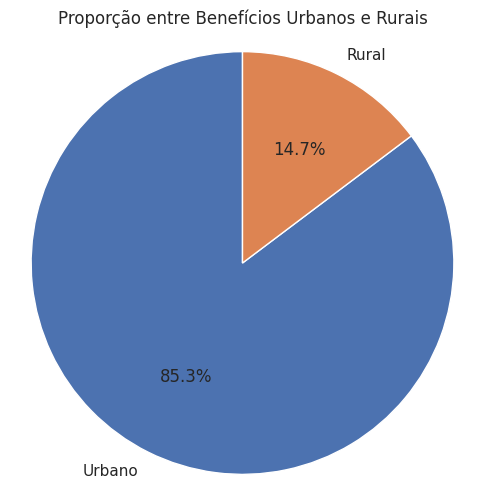

In [277]:
data = con.value_counts('Clientela')
labels = data.index

plt.figure(figsize=(6, 6))
plt.title('Proporção entre Benefícios Urbanos e Rurais')

plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
)

plt.axis('equal')
plt.show()

In [282]:
df = con.dropna(subset=['Clientela', 'Região', 'UF Res'])

prop_estado = (
    df
    .groupby(['UF Res', 'Clientela'])
    .size()
    .reset_index(name='Count')
)

prop_estado['Proporcao'] = (
    prop_estado['Count'] /
    prop_estado.groupby('UF Res')['Count'].transform('sum')
)

prop_regiao = (
    df
    .groupby(['Região', 'Clientela'])
    .size()
    .reset_index(name='Count')
)

# calcula proporção dentro da região
prop_regiao['Proporcao'] = (
    prop_regiao['Count'] /
    prop_regiao.groupby('Região')['Count'].transform('sum')
)

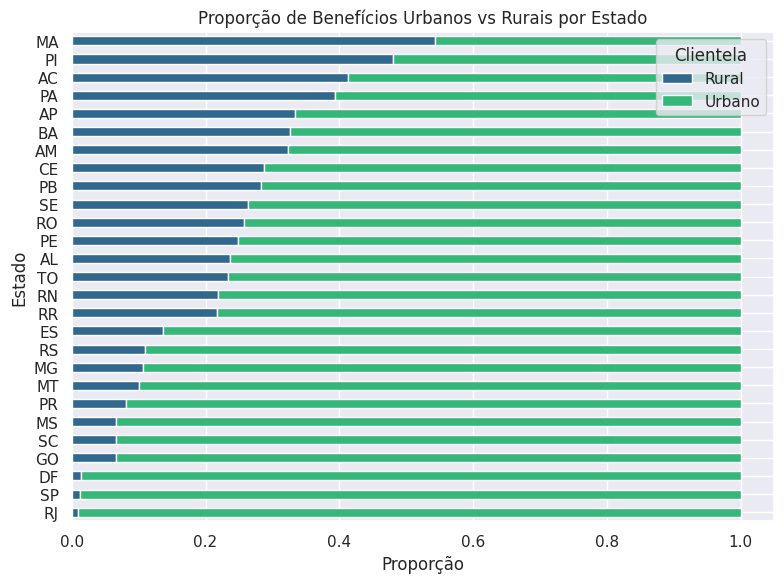

In [283]:
pivot_estado = prop_estado.pivot(
    index='UF Res',
    columns='Clientela',
    values='Proporcao'
).fillna(0)

pivot_estado = pivot_estado.sort_values(by='Rural')

pivot_estado.plot(
    kind='barh',
    stacked=True,
    figsize=(8, 6),
    color=sns.color_palette("viridis", pivot_estado.shape[1])
)

plt.title('Proporção de Benefícios Urbanos vs Rurais por Estado')
plt.xlabel('Proporção')
plt.ylabel('Estado')

plt.legend(title='Clientela')
plt.tight_layout()
plt.show()

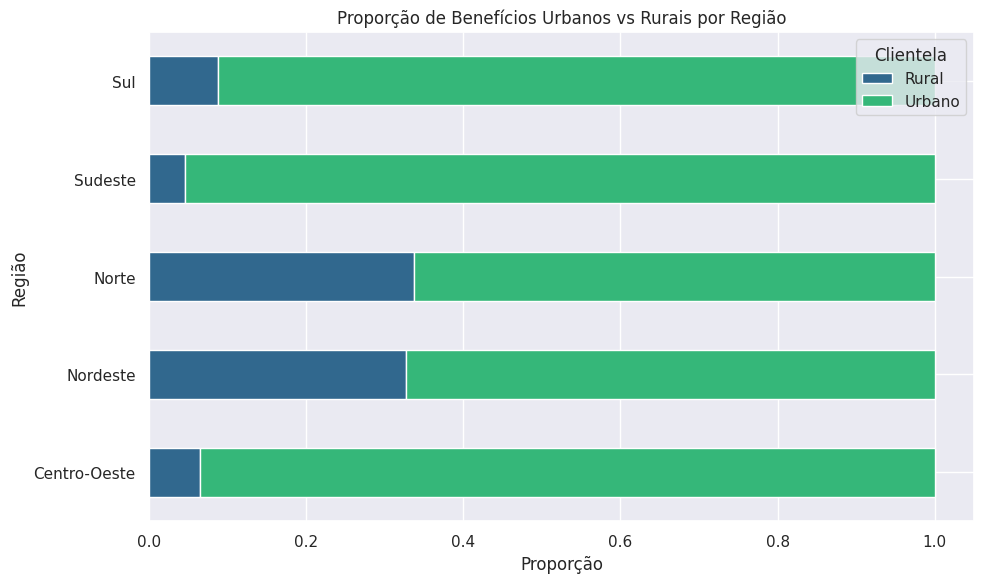

In [285]:
pivot_regiao = prop_regiao.pivot(
    index='Região',
    columns='Clientela',
    values='Proporcao'
).fillna(0)

pivot_regiao.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette("viridis", pivot_regiao.shape[1])
)

plt.title('Proporção de Benefícios Urbanos vs Rurais por Região')
plt.xlabel('Proporção')
plt.ylabel('Região')

plt.legend(title='Clientela')
plt.tight_layout()
plt.show()

## Renda

In [286]:
# agrupamento por similaridade das espécies de benefícios
grupos_beneficios = {
    'Aposentadorias': con[con['Espécie'].isin([41, 42, 46, 57])],
    'Benef Incapidade': con[con['Espécie'].isin([31,91,32,92])],
    'Pensões':  con[con['Espécie']==21],
    'Geral': con
}

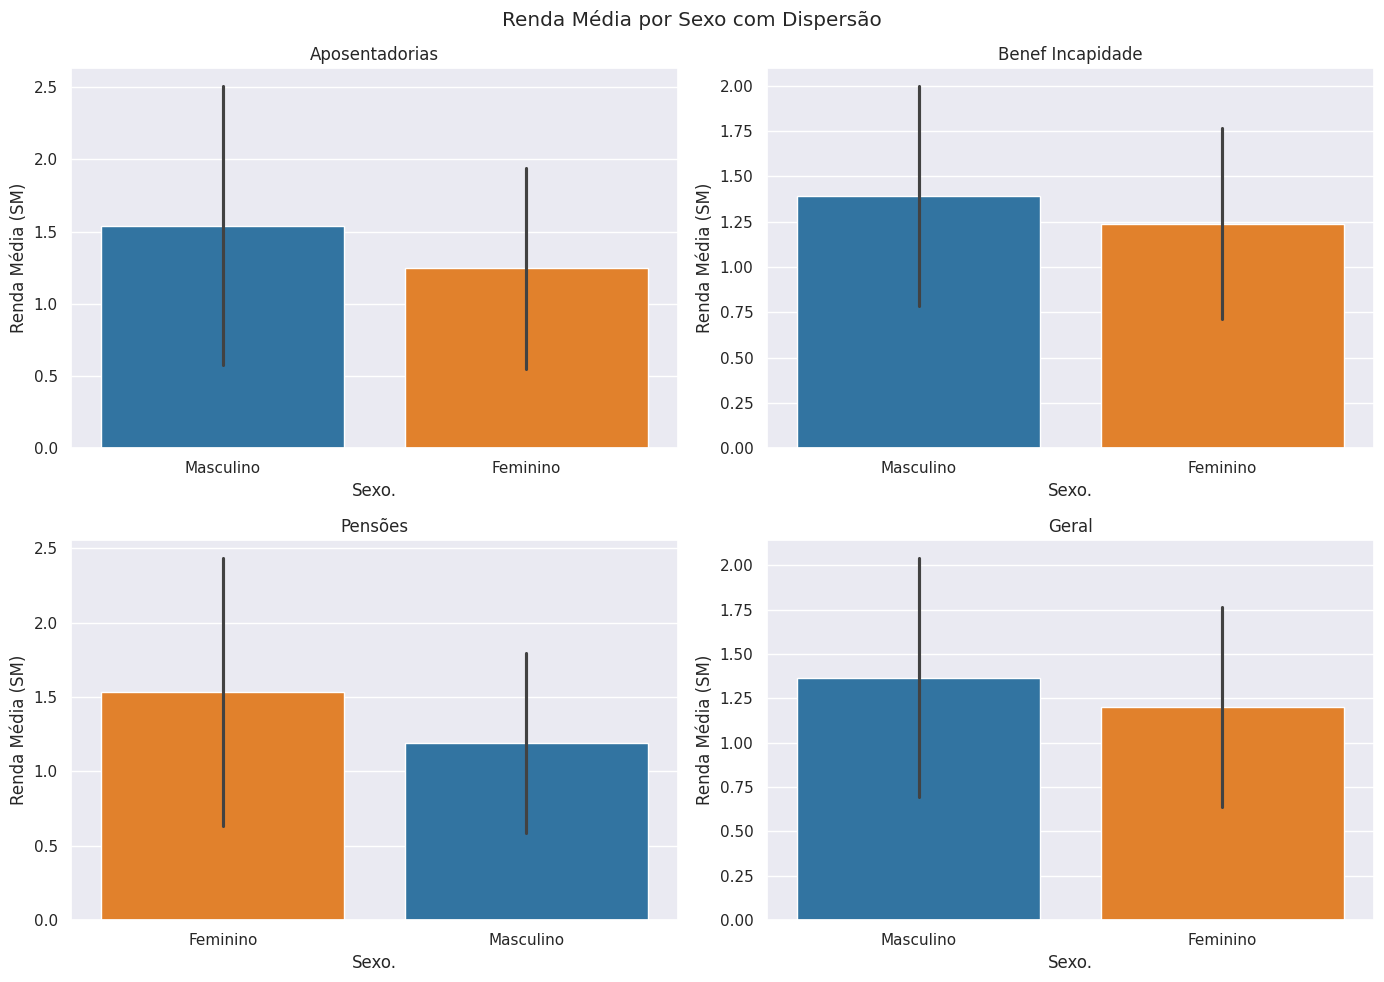

In [287]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (nome, grupo) in enumerate(grupos_beneficios.items()):

    sns.barplot(
        data=grupo,
        x='Sexo.',
        y='Qt SM RMI',
        ax=axes[i],
        palette=color_map,
        errorbar='sd',
        hue='Sexo.'
    )

    axes[i].set_title(nome)
    axes[i].set_ylabel('Renda Média (SM)')

plt.suptitle('Renda Média por Sexo com Dispersão')
plt.tight_layout()
plt.show()

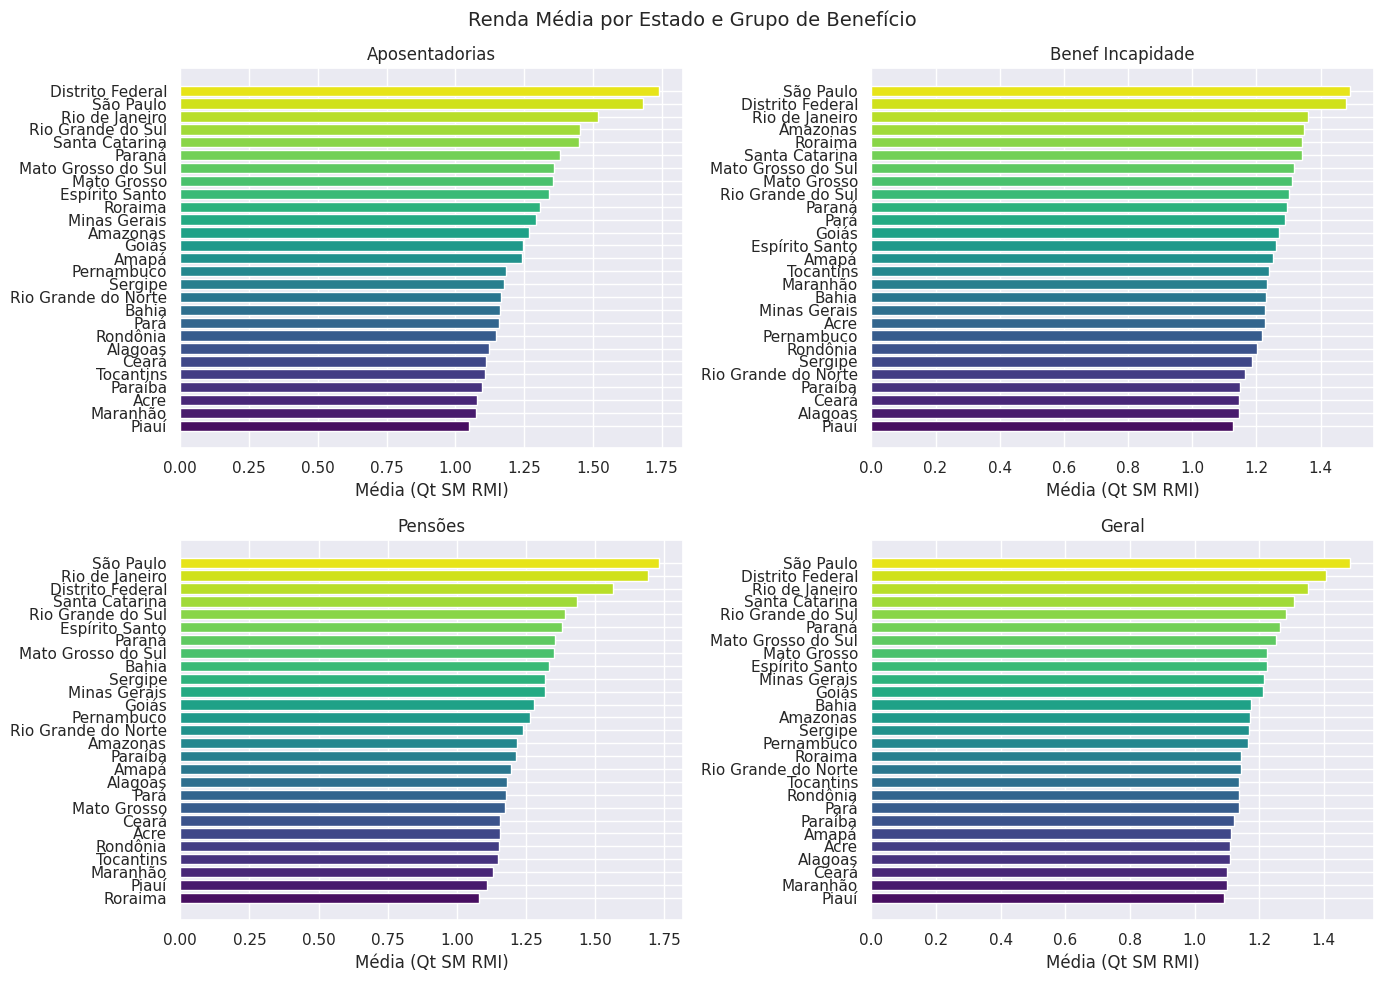

In [288]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (nome, grupo) in enumerate(grupos_beneficios.items()):

    ren_dist = (
        grupo.groupby('UF Res')['Qt SM RMI']
        .mean()
        .sort_values()
    )

    # Paleta viridis proporcional ao número de estados
    colors = sns.color_palette("viridis", len(ren_dist))

    axes[i].barh(
        [nomes_ufs[uf] for uf in ren_dist.index],
        ren_dist.values,
        color=colors
    )

    axes[i].set_title(nome)
    axes[i].set_xlabel('Média (Qt SM RMI)')
    axes[i].set_ylabel('')

plt.suptitle('Renda Média por Estado e Grupo de Benefício', fontsize=14)
plt.tight_layout()
plt.show()

## Proporção Entre Benefícios Concedidos e Indeferidos


In [292]:
# concatena as bases de concedidos e indeferios, excluído os concedidos judicialmente ou
# por recurso administrativo

colunas = ['APS', 'Espécie', 'Espécie.1', 'Sexo.', 'Clientela', 'TMC']
despachados = pd.concat(
    [
        con[~con['Despacho'].isin([4, 3])][colunas].assign(Resultado='Concedido'),
        ind[colunas].assign(Resultado='Indeferido')
    ]
)



In [293]:
prop = (
    despachados[despachados['Espécie'].isin([21, 25, 31, 32, 91, 91, 41, 42, 46, 57, 87, 88])]
    .groupby(['Espécie.1', 'Resultado'])
    .size()
    .reset_index(name='Count')
)

prop['Proporcao'] = (
    prop['Count'] /
    prop.groupby('Espécie.1')['Count'].transform('sum')
) * 100


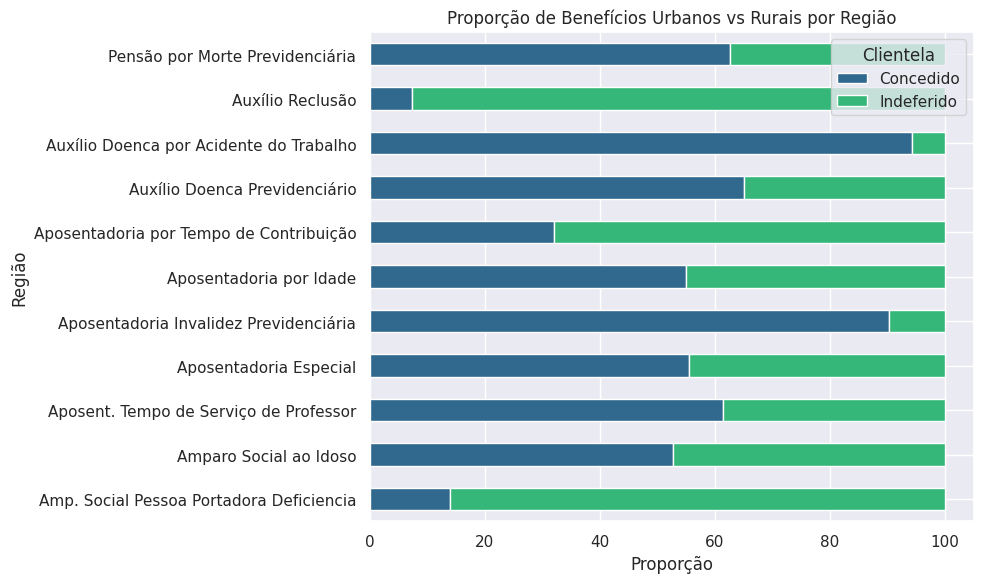

In [294]:
pivot_prop = prop.pivot(
    index='Espécie.1',
    columns='Resultado',
    values='Proporcao'
).fillna(0)

pivot_prop.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    color=sns.color_palette("viridis", pivot_prop.shape[1])
)

plt.title('Proporção de Benefícios Urbanos vs Rurais por Região')
plt.xlabel('Proporção')
plt.ylabel('Região')

plt.legend(title='Clientela')
plt.tight_layout()
plt.show()